In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak
import mplhep as hep
import glob
import tqdm
plt.style.use([hep.style.ATLAS, hep.style.firamath])

In [54]:
sig_files = glob.glob("/eos/project/a/agentic/public/bonn/DYToMuMu_pomflux_Pt-30_TuneCP5_13TeV-pythia8/*root")
bkg_files = glob.glob("/eos/project/a/agentic/public/bonn/ZToMuMu_M-50To120_TuneCP5_13TeV-powheg-pythia8/*root")
data_files = glob.glob("/eos/project/a/agentic/public/bonn/2016H/*root")
#print(sig_files)
sig_files = [f'{f}:pfExtractor/pfTree' for f in sig_files[:3]]
bkg_files = [f'{f}:pfExtractor/pfTree' for f in bkg_files[:3]]
data_files = [f'{f}:pfExtractor/pfTree' for f in data_files[:2]]
sig = uproot.concatenate(sig_files)
bkg = uproot.concatenate(bkg_files)
data = uproot.concatenate(data_files)
#print(sig.fields)

In [50]:
print(sig.fields)

['run', 'lumi', 'event', 'genWeight', 'nCands', 'nMuons', 'nVertices', 'genPt', 'genEta', 'genPhi', 'genMass', 'genEnergy', 'genPx', 'genPy', 'genPz', 'genPdgId', 'genCharge', 'genStatus', 'genParticleId', 'genMotherIndex', 'genDaughterIndex', 'IsoMu24', 'nJets', 'jetPt', 'jetEta', 'jetPhi', 'jetMass', 'jetEnergy', 'jetPx', 'jetPy', 'jetPz', 'jetArea', 'jetRawPt', 'jetRawMass', 'jetNeutralHadronEnergy', 'jetNeutralHadronFraction', 'jetChargedHadronEnergy', 'jetChargedHadronFraction', 'jetPhotonEnergy', 'jetPhotonFraction', 'jetElectronEnergy', 'jetElectronFraction', 'jetMuonEnergy', 'jetMuonFraction', 'jetHFHadronEnergy', 'jetHFHadronFraction', 'jetHFEMEnergy', 'jetHFEMFraction', 'jetCharge', 'jetParticleId', 'jetBTagCSVv2', 'jetBTagDeepB', 'jetBTagDeepC', 'jetBTagDeepFlavB', 'jetNConstituents', 'jetNCharged', 'jetNNeutrals', 'jetNPV', 'jetPUID', 'muonPt', 'muonEta', 'muonPhi', 'muonMass', 'muonEnergy', 'muonPx', 'muonPy', 'muonPz', 'muonCharge', 'muonVx', 'muonVy', 'muonVz', 'muonDxy'

## Muon + Z preselection

In [66]:
#print(len(sig.candPt))
def apply_sel(arr):
    '''
    sel_mask = ( 
                 (arr.IsoMu24 == 1) & 
                 (ak.sum( (arr.muonPt > 22) & (arr.muonIsLoose == 1) , axis=1) >= 2)
               )
    return arr[sel_mask]
    '''
    
        # ---- Step 1: initial loose muon selection ----
    # Require IsoMu24 trigger and at least two loose muons with pT > 22
    loose_muon_mask = (arr.muonPt > 22) & (arr.muonIsLoose == 1)
    n_loose = ak.sum(loose_muon_mask, axis=1)
    sel_mask = (arr.IsoMu24 == 1) & (n_loose >= 2)
    
    # Apply this mask to reduce the dataset
    arr_sel = arr[sel_mask]
    
    # ---- Step 2: Z reconstruction from the two leading loose muons ----
    # Filter to only loose muons (order is preserved, so the first two are the highest-pT loose ones)
    loose_pt  = arr_sel.muonPt[loose_muon_mask[sel_mask]]   # careful: need to apply mask to filtered array
    loose_eta = arr_sel.muonEta[loose_muon_mask[sel_mask]]
    loose_phi = arr_sel.muonPhi[loose_muon_mask[sel_mask]]
    
    # Because we already required n_loose >= 2, every event has at least two entries here
    mu1_pt  = loose_pt[:, 0]
    mu2_pt  = loose_pt[:, 1]
    mu1_eta = loose_eta[:, 0]
    mu2_eta = loose_eta[:, 1]
    mu1_phi = loose_phi[:, 0]
    mu2_phi = loose_phi[:, 1]
    
    # ---- Step 3: compute Z kinematics (massless approximation) ----
    # Invariant mass: m^2 = 2 * pT1 * pT2 * (cosh(Δη) - cos(Δφ))
    m_ll = np.sqrt(2 * mu1_pt * mu2_pt * (np.cosh(mu1_eta - mu2_eta) - np.cos(mu1_phi - mu2_phi)))
    
    # Transverse momentum of the Z: vector sum of the two muon pT vectors
    px = mu1_pt * np.cos(mu1_phi) + mu2_pt * np.cos(mu2_phi)
    py = mu1_pt * np.sin(mu1_phi) + mu2_pt * np.sin(mu2_phi)
    pt_ll = np.sqrt(px**2 + py**2)
    
    # ---- Step 4: apply Z kinematic cuts (example values) ----
    z_cut = (m_ll > 80) & (m_ll < 100) & (pt_ll < 15)   # adjust thresholds as needed

    return arr_sel[z_cut]
    
sig = apply_sel(sig)
bkg = apply_sel(bkg)
data = apply_sel(data)
print(sig.muonPt)

[[37.6, 29.5], [48.5, 36.5, ..., 0.731], ..., [36.7, 30.3, 1.21, 1.01, 0.789]]


## Remove Z from PF candidates

In [67]:
def remove_overlapping_candidates(arr,dR_cut=0.01,n_leading=2):
    for feature in arr.fields:
        #print(feature)
        if 'muon' in feature and feature != 'muonIsLoose':
            column = arr[feature][arr['muonIsLoose']==1]
            arr[feature] = column
        arr['muonIsLoose'] = arr['muonIsLoose'][arr['muonIsLoose']==1]

    leading_eta = ak.pad_none(arr['muonEta'], n_leading, clip=True)
    leading_phi = ak.pad_none(arr['muonPhi'], n_leading, clip=True)
    
    dummy = 999.0
    leading_eta_filled = ak.fill_none(leading_eta, dummy)
    leading_phi_filled = ak.fill_none(leading_phi, dummy)
    
    candEta_exp = arr.candEta[:, :, None]          # (N, M, 1)
    candPhi_exp = arr.candPhi[:, :, None]          # (N, M, 1)    
    
    # Leading arrays are (N, n_leading) – broadcasting aligns to last dimension
    deta = candEta_exp - leading_eta_filled[:, None, :]   # (N, M, L)
    dphi = candPhi_exp - leading_phi_filled[:, None, :]   # (N, M, L)
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi
    deltaR = np.sqrt(deta**2 + dphi**2)                    # (N, M, L)
    
    # 5. For each candidate, check if it overlaps with ANY leading muon
    #    We take the minimum ΔR across the leading-muon dimension (axis=2)
    min_deltaR = ak.min(deltaR, axis=2)        # (N, M)

    # 6. Create a mask for candidates that DO NOT overlap (keep them)
    keep_mask = min_deltaR >= dR_cut           # True = keep, False = remove
    
    keep_mask = (keep_mask) & (arr.candPt > 0.5) & (arr.candFromPV==3)
    
    for feature in arr.fields:
        if 'cand' in feature:
            filtered = arr[feature][keep_mask]
            arr[feature] = filtered
            
remove_overlapping_candidates(sig)
remove_overlapping_candidates(bkg)
remove_overlapping_candidates(data)
#print(sig.muonPt)

In [68]:
print(sig.candPt)
print(ak.ravel(data.candEta))

[[2.12, 1.11, 0.975, 0.732], [1.6, 1.54], ..., [1.52, 0.651, 0.63, 0.515]]
[0.0181, -1.39, -1.3, -1.14, 1.89, 0.363, ..., -0.984, 1.92, 1.94, 0.454, 1.65]


In [69]:
def fill_with_random(arr):
    if isinstance(arr, ak.Array):
        # If it's a record or other, adjust logic, but for lists:
        if ak.fields(arr) == []:  # simple list of numbers
            counts = ak.num(arr)  # per top-level list
            flat = np.random.normal(1.0,0.00001,size=sum(counts))
            return ak.unflatten(flat, counts)
        else:
            # For nested structure, recursively fill each sublist
            # Using ak.ArrayBuilder for simplicity here (not vectorized)
            builder = ak.ArrayBuilder()
            for sub in arr:
                builder.append(fill_with_random(sub))   # recursion
            return builder.snapshot()
    else:
        # base case: a scalar or something else; return random normal
        return np.random.normal()

def dataplot(arr,binrange):
    bin_counts, bin_edges, patches = plt.hist(arr, alpha=0.0, bins=binrange)
    print("Integral", np.sum(bin_counts))
    y_error = np.sqrt(bin_counts)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.errorbar(x=bin_centres, y=bin_counts,
             yerr=y_error, fmt='o', capsize=2, color='k', label='Data')
    
    return np.sum(bin_counts)

def mcplot(arr,binrange,integral,label):
    weights = np.full(len(arr,), integral/len(arr))
    plt.hist(arr,bins=binrange,weights=weights,histtype='step',label=label)
    
def plot(name,arr_list,label,binrange,logy=True,pdata=None):
    fig,ax = plt.subplots()
    if logy:
        ax.set_yscale('log')
    
    if pdata is not None:
        integral = dataplot(pdata,binrange=binrange)
    else:
        integral = 1
    mcplot(arr_list[0],binrange,integral,label='Single-diffractive')
    mcplot(arr_list[1],binrange,integral,label='Non-diffractive')
        
    plt.text(0.4,1.02,"(OpenData)",transform=ax.transAxes,fontsize=22)
    plt.legend(fontsize=21)
    plt.xlabel(label)
    plt.ylabel("Arbitrary units")
    hep.cms.label(loc=0,fontsize=22)
    plt.savefig(f'/eos/user/b/bmaier/www/bonn/{name}.png',dpi=200,bbox_inches='tight')
    plt.savefig(f'/eos/user/b/bmaier/www/bonn/{name}.pdf',bbox_inches='tight')

Integral 114597.0
Integral 127467.0


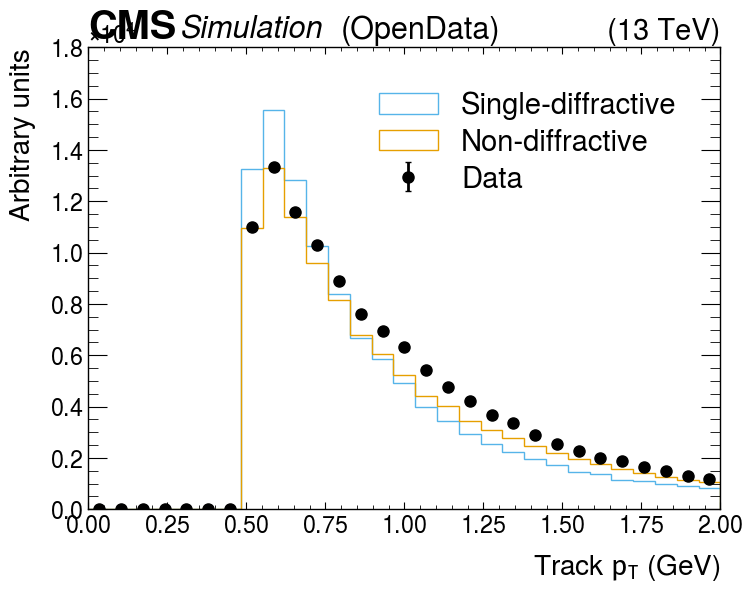

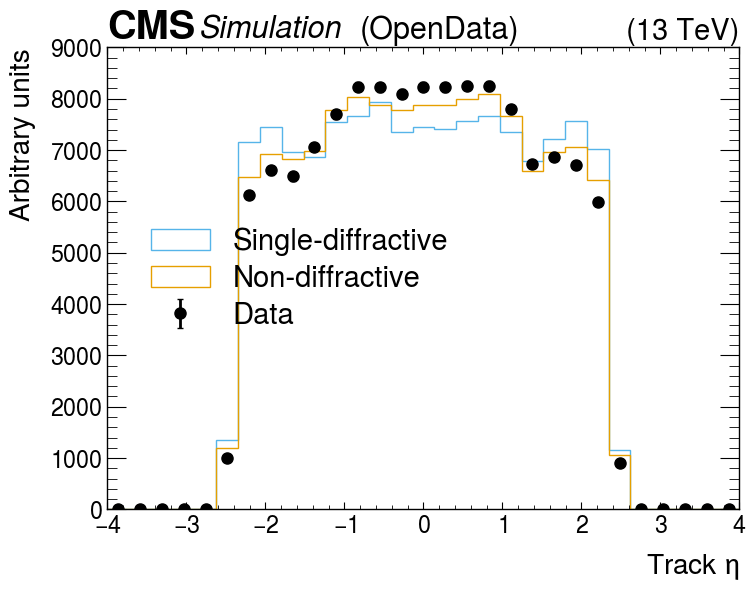

In [70]:
plot("trackPt",[ak.ravel(fill_with_random(sig.candPt)*sig.candPt),ak.ravel(fill_with_random(bkg.candPt)*bkg.candPt)],"Track $p_{T}$ (GeV)",np.linspace(0,2,30),logy=False,pdata=ak.ravel(data.candPt))
plot("trackEta",[ak.ravel(sig.candEta),ak.ravel(bkg.candEta)],"Track $\\eta$",np.linspace(-4,4,30),logy=False,pdata=ak.ravel(data.candEta))

In [59]:
def compute_cumulant_vectorized(pt_arr, eta_arr, max_eta=2.5, min_pt=0.5):
    # apply pt cut

    print("Original:",pt_arr)
    filled = fill_with_random(pt_arr)*pt_arr
    print("Smeared:",filled)
    pt_arr = filled
    pt_cut = pt_arr > min_pt
    pt_f = pt_arr[pt_cut]
    eta_f = eta_arr[pt_cut]
    # apply eta cut
    eta_abs = abs(eta_f) < max_eta
    pt_ff = pt_f[eta_abs]
    eta_ff = eta_f[eta_abs]
    # compute max and min per event
    max_eta_per = ak.max(eta_ff, axis=1)
    min_eta_per = ak.min(eta_ff, axis=1)
    # compute diffs
    diff_r = abs(max_eta - max_eta_per)
    diff_l = abs(-max_eta - min_eta_per)  # same as abs(max_eta + min_eta_per)
    # final cumulant = max of the two diffs
    final = ak.max([diff_r, diff_l], axis=0)  # element-wise max between the two arrays
    # handle events with no tracks: set to 0 or some default
    # we can check if there are any tracks left: ak.num(eta_ff, axis=1) == 0
    # For those, we set to 0 (or maybe -1)
    has_tracks = ak.num(eta_ff, axis=1) > 0
    final = ak.where(has_tracks, final, 0.0)
    return final

In [71]:
sig_cumu = compute_cumulant_vectorized(sig.candPt,sig.candEta)
bkg_cumu = compute_cumulant_vectorized(bkg.candPt,bkg.candEta)
data_cumu = compute_cumulant_vectorized(data.candPt,data.candEta)

Original: [[2.12, 1.11, 0.975, 0.732], [1.6, 1.54], ..., [1.52, 0.651, 0.63, 0.515]]
Smeared: [[2.12, 1.11, 0.975, 0.732], [1.6, 1.54], ..., [1.52, 0.651, 0.63, 0.515]]
Original: [[1.4, 1.38, 1.09, 0.991, 0.933, 0.844, 0.753, 0.589, 0.557], ..., [3.55, ...]]
Smeared: [[1.4, 1.38, 1.09, 0.991, 0.933, 0.844, 0.753, 0.589, 0.557], ..., [3.55, ...]]
Original: [[1.96, 0.726, 0.638, 0.592, 0.527, 0.524, 0.51], ..., [1.83, 1.41, ..., 0.543]]
Smeared: [[1.96, 0.726, 0.638, 0.592, 0.527, 0.524, 0.51], ..., [1.83, 1.41, ..., 0.543]]


## Gap Flow

In [61]:
@numba.njit
def energy_gap_flow_score(
        eta: np.ndarray,
        pt: np.ndarray,
        side: int,
        eta_min: float,
        eta_max: float,
        pt_min: float,
        beta: float,
        q0: float
    ):
    """
    Energy Gap Flow 'G' or 'cumulant expansion',
    as a new diffraction / rapidity gap observable with pt-dependence.
    
    This version is by construction in between 0 < G <= 1,
    where values close to 1 means a 'complete detector gap'
    and 0 means essentially no gap ~ non-diffractive.

    Args:
        eta:     pseudorapidity of (charged) particles
        pt:      transverse momentum of (charged) particles (GeV)
        side:    (-1, 1) backward / forward
        eta_min: minimum oriented fiducial eta (e.g. -2.5)
        eta_max: maximum absolute fiducial eta (e.g.  2.5)
        pt_min:  minimum fiducial pt threshold (e.g.  0.2) (GeV)
        beta:    algorithm 'correlation length' parameter (e.g. 0.1)
        q0:      algorithm 'energy scale' parameter (e.g. 2.0) (GeV)

    Combine both hemispheres per event by calling twice:
    max(energy_gap_flow_score(side=-1), energy_gap_flow_score(side=1))
    """
    eta = ak.to_numpy(eta)
    pt = ak.to_numpy(pt)
    
    if side != -1 and side != 1:
        raise ValueError('energy_gap_flow_score: side must be -1 or +1')
    if eta_max <= eta_min:
        raise ValueError('energy_gap_flow_score: eta_max must exceed eta_min')
    if pt_min < 0.0:
        raise ValueError('energy_gap_flow_score: pt_min must be non-negative')
    if beta <= 0.0:
        raise ValueError('energy_gap_flow_score: beta must be positive')
    if q0 <= 0.0:
        raise ValueError('energy_gap_flow_score: q0 (GeV) must be positive')

    oriented = side * eta
    mask    = (eta_min < oriented) & (oriented < eta_max) & (pt > pt_min)
    u       = oriented[mask]
    side_pt = pt[mask]

    if u.size == 0:
        return 1.0

    order   = np.argsort(u)
    u       = u[order]
    side_pt = side_pt[order]

    tail_pt    = np.sum(side_pt)
    previous_u = eta_min
    numerator  = 0.0

    for i in range(u.size):
        upper_weight = np.exp(beta * (u[i] - eta_max))
        lower_weight = np.exp(beta * (previous_u - eta_max))
        numerator += np.exp(-tail_pt / q0) * (upper_weight - lower_weight)
        tail_pt -= side_pt[i]
        previous_u = u[i]

    numerator    += 1.0 - np.exp(beta * (previous_u - eta_max))
    normalization = -np.expm1(-beta * (eta_max - eta_min))
    score = numerator / normalization

    return min(1.0, max(0.0, score))

In [72]:
sig_egf = []
for evt in tqdm.tqdm(range(len(sig))):#.candEta
    sig_right = energy_gap_flow_score(sig.candEta[evt],sig.candPt[evt],1,-2.5,2.5,0.5,0.1,2.0)
    sig_left = energy_gap_flow_score(sig.candEta[evt],sig.candPt[evt],-1,-2.5,2.5,0.5,0.1,2.0)
    sig_egf.append(np.max((sig_right,sig_left)))
bkg_egf = []
for evt in tqdm.tqdm(range(len(bkg))):#.candEta
    bkg_right = energy_gap_flow_score(bkg.candEta[evt],bkg.candPt[evt],1,-2.5,2.5,0.5,0.1,2.0)
    bkg_left = energy_gap_flow_score(bkg.candEta[evt],bkg.candPt[evt],-1,-2.5,2.5,0.5,0.1,2.0)
    bkg_egf.append(np.max((bkg_right,bkg_left)))
data_egf = []
for evt in tqdm.tqdm(range(len(data))):#.candEta
    data_right = energy_gap_flow_score(data.candEta[evt],data.candPt[evt],1,-2.5,2.5,0.5,0.1,2.0)
    data_left = energy_gap_flow_score(data.candEta[evt],data.candPt[evt],-1,-2.5,2.5,0.5,0.1,2.0)
    data_egf.append(np.max((data_right,data_left)))   

100%|██████████| 5966/5966 [00:20<00:00, 288.79it/s]


Integral 5966.0
Integral 5966.0


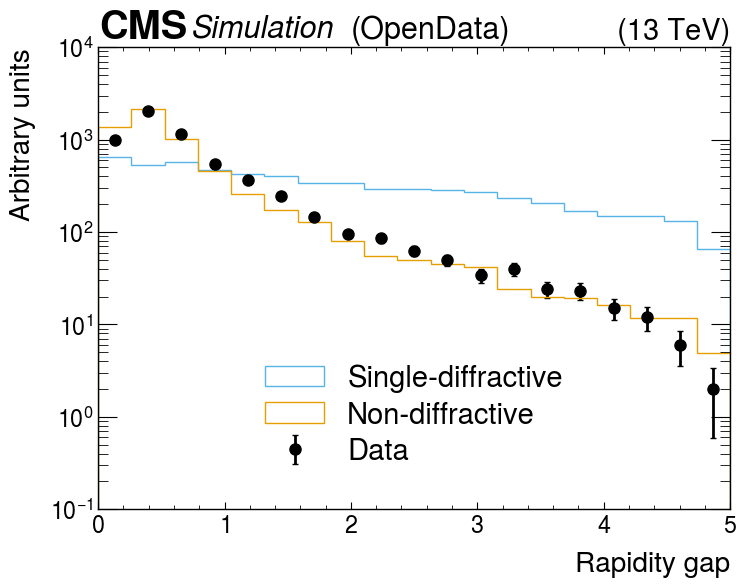

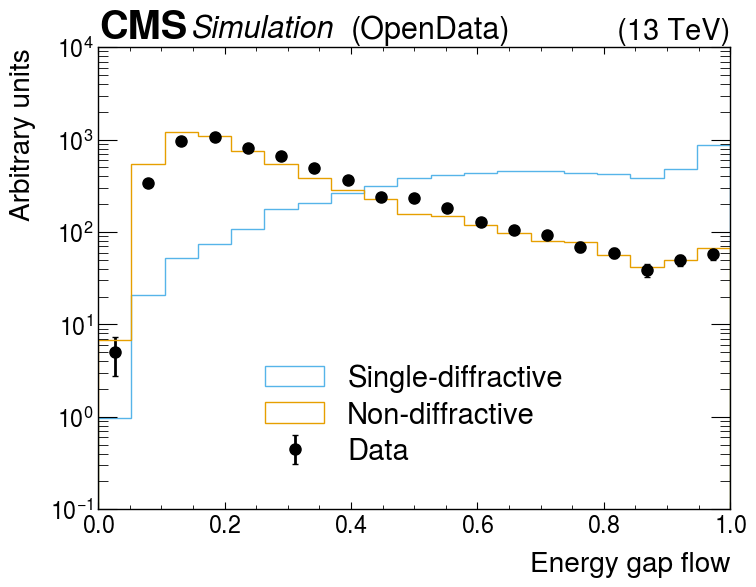

In [73]:
plot("Max rapidity gap",[sig_cumu,bkg_cumu],"Rapidity gap",np.linspace(0,5,20),pdata=data_cumu)
plot("EGF",[sig_egf,bkg_egf],"Energy gap flow",np.linspace(0,1,20),pdata=data_egf)

40763
40763


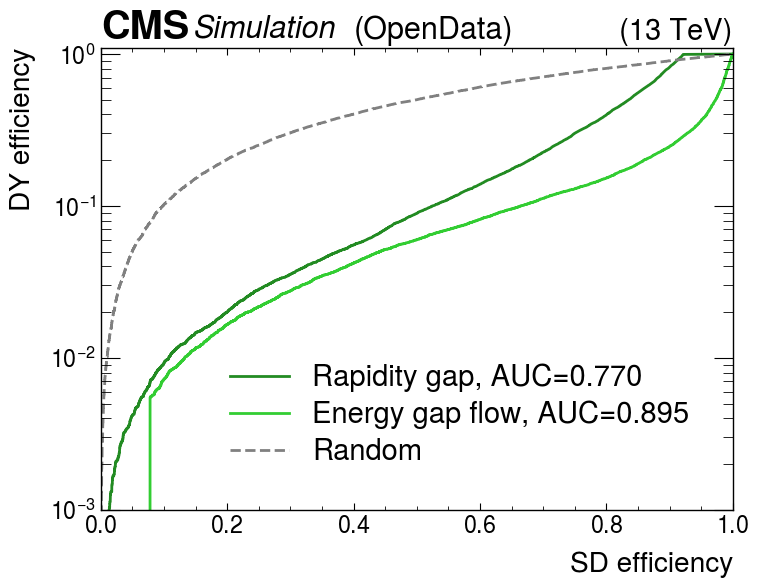

In [74]:
from sklearn import metrics
import random
y = np.array(np.concatenate((np.array([1 for i in range(len(sig_cumu))]),np.array([0 for i in range(len(bkg_cumu))]))))
print(len(y))
scores = np.concatenate((sig_cumu,bkg_cumu))
scores_egf = np.concatenate((sig_egf,bkg_egf))
print(len(scores))

fig, ax = plt.subplots()
ax.set_yscale('log')
hep.cms.label(loc=0,fontsize=22)
plt.text(0.4,1.02,"(OpenData)",transform=ax.transAxes,fontsize=22)
fpr, tpr, thresholds = metrics.roc_curve(y, scores)
auc = metrics.auc(fpr, tpr)

fpr_egf, tpr_egf, thresholds_egf = metrics.roc_curve(y, scores_egf)
auc_egf = metrics.auc(fpr_egf, tpr_egf)

rfpr, rtpr, rthresholds = metrics.roc_curve(y, [random.random() for i in range(len(scores))])
plt.plot(tpr, fpr, label=f'Rapidity gap, AUC={auc:.3f}', color='forestgreen')
plt.plot(tpr_egf, fpr_egf, label=f'Energy gap flow, AUC={auc_egf:.3f}', color='limegreen')
plt.plot(rtpr, rfpr, ls='--', label='Random', color='grey')
plt.ylim(0.001,1.1)
plt.xlabel('SD efficiency')
plt.ylabel('DY efficiency')
plt.legend(fontsize=21)
plt.savefig(f'/eos/user/b/bmaier/www/bonn/roc.png',dpi=200,bbox_inches='tight')
plt.savefig(f'/eos/user/b/bmaier/www/bonn/roc.pdf',bbox_inches='tight')